# LightGBM Regression - NFL TV Ratings

## Motivation

This notebook fits a LightGBM gradient boosting regressor with Optuna hyperparameter optimzation to predict intra-market TV ratings on NFL games. It is the third model in a progression where we investigate different ML algorithms' out-of-sample prediction capabilities on tabular data:


| Model | Val R² | Notes |
|---|---|---|
| Ridge (Linear) | 91.3% | Polynomial + Lasso selection + OHE market/team interactions |
| MLP neural network (OHE) | 91.2% | [2022 -- 1024 -- 256 -- 64 -- 1]  (2,291,335 MLP params), pure NumPy, Adam optimizer, no embeddings |
| MLP neural network w/ Embeddings | 90.9% | [245 -- 128 -- 64 -- 1]  (39,809 MLP params), Adam Optimizer, bilinear team×market embedding |
| **LightGBM** | **TBD** | Native categoricals, two-phase Optuna HPO, raw target |

**Initial Observations** The MLP with embeddings clearly is a leaner model from # parameters perspective, yet we also are describing less variance (yet only slightly, within architecture/hyperparameter tuning reach). The neural network with full cardinality benefits from the lossless encoding of the categorical features, yet the model itself is more expensive. The Linear Model also uses full cardinality, yet less total model parameters, and still does better than the neural network. 

* > ML literature has consistently shown that tree-based models are better equipped than Neural Networks to handle tabular data, especially data with high categorical cardinality. We test that hypothesis in this notebook, as well as comparing a gradient boosted tree-based method to the linear model benchmark. 

**Strategy:** 7 natively-handled LightGBM categorical features replace 1,904 OHE columns. Two engineered features capture market draw strength relative to prior-year market average. `TimeSeriesSplit` expanding-window CV prevents training data leakage. Two-phase Optuna (300 wide + 200 refined trials) drives hyperparameter search.


## Target Transform: Why We Train on Raw Ratings

Prior iterations of this notebook applied `np.log1p` to the target before training and inverted predictions with `np.expm1` before computing R². The rationale was the same as for linear regression: compressing a right-skewed target can stabilize variance and improve fit on smaller values.

For gradient boosted trees, however, this tradeoff is less clear-cut:

- LightGBM already models nonlinear relationships through splits. It does not assume a linear relationship between features and target
- Log-compressing the target changes the loss landscape: the model minimizes MSE on log scale, which implicitly up-weights errors on low-rating games relative to high-rating games
- R² on the raw scale is the interpretable metric for comparison across all four models; optimizing on log scale and evaluating on raw scale creates a mismatch

This notebook trains directly on raw target (`AA__000_`) and evaluates R² on the same scale. This makes the objective function and evaluation metric consistent, and allows direct comparison against the Ridge and MLP baselines.

> Because of the way gradient boosting algorithms work, there can be a small bias toward learning higher rated games, because early trees in the ensemble will prioritize correcting the largest residuals first. LightGBM's split criterion for MSE can amplify this as well, so the algorithm can gravitate toward splits with large gain even when they affect small subsets of the dataset.

> Even still, later trees in the model will adapt toward the lower-rated games, and decision trees handle nonlinearity natively. They have a structural workaround that a linear model doesn't have. Therefore the decision to not transform the target variable for this modeling framework was an emperical one - after examining the plot_actual_vs_predicted plot and visually searching for skew, it was determined that a log transform was not necessary. When possible, training on the raw target is preferred - we do not want to introduce a bias to correct a different bias that was never truely there.  

In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
import json, pickle, os, sys, re, hashlib
from datetime import date
from pathlib import Path

optuna.logging.set_verbosity(optuna.logging.WARNING)
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

# ── Config ────────────────────────────────────────────────────────────────
# The table located at DATA_PATH is the final result of our SQL project also located in the repo
DATA_PATH         = r"C:/Users/ASR10/PyPr/nfl_python_local/111B/nfl_python/nfl_data_pipeline/NFLTV_ML_11_rebuilt.csv"
SAVED_MODELS_DIR  = "C:/Users/ASR10/PyPr/nfl_python_local/111B/nfl_python/neural_network/saved_models"
STUDY_NICKNAME    = "lgbm_nfl_v3_raw"

NUM_THREADS           = 4
NUM_BOOST_ROUND       = 3500
EARLY_STOPPING_ROUNDS = 150
N_SPLITS              = 4            # time series cross validation carried out below
TEST_SIZE             = 4100         # 4100 rows is about 1 season of data
TARGET_COL            = 'AA__000_'   # Household Average Audience x1000 (how many households watched the game)

print(f"LightGBM {lgb.__version__}  |  Optuna {optuna.__version__}")


LightGBM 4.5.0  |  Optuna 4.5.0


In [2]:
from tv_ratings_preprocessing import (
    isdivision, build_concurrent_features, build_normalized_market_draw,
)
from MLP_analysis import plot_actual_vs_predicted, plot_subset_r2
from lightgbm_utils import (
    sanitize_feature_name, enforce_feature_types,
    feature_importance_plot, generate_shap_summary_lgbm_fast,
    extract_shap_contributions, save_lightgbm_artifacts_v2,
)

print("Modules loaded.")

Modules loaded.


## 2. Data Loading & Preprocessing


In [3]:
df = pd.read_csv(DATA_PATH, low_memory=False)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values('Date').reset_index(drop=True)  # sorted by date for time series cross validation
df = df[df['Day'] == 'Sun'].copy()                  # keep only sunday games (this is intended to be a non-prime-time dataset, but some snuck in)
df = df[df['timeofday'] != 'morning'].copy()        # rule out international games (a subset of prime-time games, they take place primarily on sunday morning)
print(f"Shape: {df.shape}")
print(f"Seasons: {df['Season'].min()} – {df['Season'].max()}")
print(f"Target range: {df[TARGET_COL].min():.1f} – {df[TARGET_COL].max():.1f}")
df[['Date', 'Season', 'week', TARGET_COL, 'at', 'ht', 'Market_abrev']].head(3)
teams = np.unique(df['at'])

Shape: (57229, 2001)
Seasons: 2010 – 2024
Target range: 3.0 – 1865.0


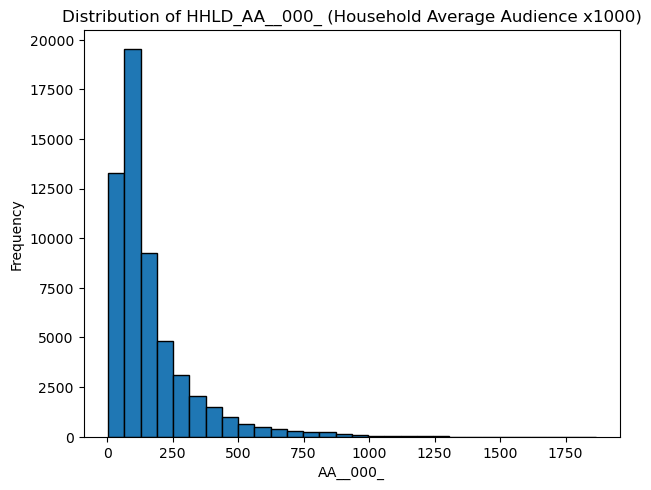

In [4]:
# View Target Distribution variable
df[TARGET_COL].plot(kind='hist', bins=30, edgecolor='black')
plt.xlabel(TARGET_COL)
plt.tight_layout()
plt.title("Distribution of HHLD_AA__000_ (Household Average Audience x1000)")
plt.show()

df = df[df['timeofday'] != 'morning'].copy()        # rule out international games (a subset of prime-time games, they take place primarily on sunday morning)

In [5]:
# # integer encode the division matchups
# df, division_mapping = encode_categorical(df, 'div_matchup')

'''
This code is bypassed because LightGBM handles categorical data natively via:
enforce_feature_types(..., for_lightgbm=True), which calls pandas.Categorical.codes internally and produces 
the integer codes that LightGBM needs
'''

'\nThis code is bypassed because LightGBM handles categorical data natively via:\nenforce_feature_types(..., for_lightgbm=True), which calls pandas.Categorical.codes internally and produces \nthe integer codes that LightGBM needs\n'

In [6]:
# build_concurrent_features is imported from the shared module, it captures the strength of viewership draw of matchups occuring concurrently.
df = build_concurrent_features(df)

In [7]:
# built_normalized_market_draw is imported from the shared module, captures home/away team's prior-year market avg normalized by that market's average draw
df = build_normalized_market_draw(df, TARGET_COL)

normalized_ht_market_draw:
count    42548.000000
mean         0.992272
std          0.367951
min          0.069906
25%          0.773809
50%          0.961828
75%          1.136732
max          2.833352
Name: normalized_ht_market_draw, dtype: float64
NaN count: 14681 (expected for Season 1 and pre-2014 rows)


In [8]:
df = df[df['Season'] > 2013].copy()  # filter to only seasons that have full time series data.
df = df.reset_index(drop=True)
print(f"After Season > 2013 filter: {df.shape}")

After Season > 2013 filter: (42548, 2008)


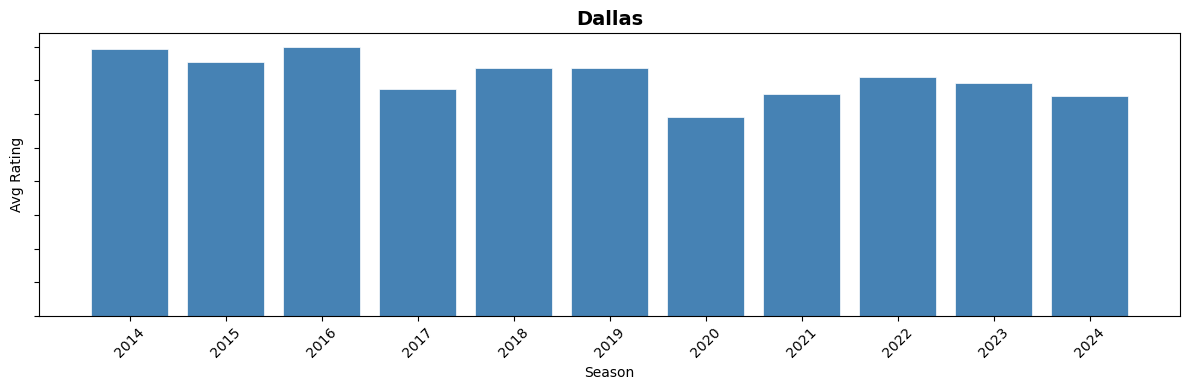

In [9]:
# Static bar chart: Dallas market avg ratings by season
_mkt_viz = (df.groupby(['Market_abrev', 'Season'])[TARGET_COL]
              .mean().reset_index()
              .rename(columns={TARGET_COL: 'market_avg_rating'}))

market = 'Dallas'
d = _mkt_viz[_mkt_viz['Market_abrev'] == market].sort_values('Season')
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(d['Season'], d['market_avg_rating'],
       color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title(market, fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Avg Rating')
ax.set_yticklabels([])
ax.set_xticks(d['Season'])
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# week: ensure numeric
df['week'] = pd.to_numeric(df['week'], errors='coerce')

# --- Feature lists ---------------------------------------------------------------
predictors_numerical = [
    'prev_market_at_year_avg', 
    'prev_market_ht_year_avg',
    'prev_year_at_market_trend_todate', 
    'prev_year_ht_market_trend_todate',
    'prev_year_at_market_trend_4', 
    'prev_year_ht_market_trend_4',
    'prev_year_market_tod_avg', 
    'prev_market_tod_trend_todate', 
    'prev_market_tod_trend_4',
    'ht_market_todate_prediction', 
    'ht_market_4_prediction',
    'at_market_todate_prediction', 
    'at_market_4_prediction',
    'market_tod_todate_prediction', 
    'market_tod_4_prediction',
    'ht_expected_wins', 
    'at_expected_wins', 
    'sum_expected_wins',
    'sumwins_m_difwins', 
    'sumwins_m_difwins_d_week',
    'ht_playoff_make_prob', 
    'ht_playoff_miss_prob',
    'at_playoff_make_prob', 
    'at_playoff_miss_prob',
    'ht_division_prob', 
    'at_division_prob',
    'ht_conference_prob', 
    'at_conference_prob',
    'ht_superbowl_prob', 
    'at_superbowl_prob',
    'diff_playoff_make_prob', 
    'diff_playoff_miss_prob',
    'diff_wins', 
    'sumwins2_diffwins2',
    'diff_division_prob', 
    'diff_conference_prob', 
    'diff_superbowl_prob',
    'week',
    # New features
    'Season', 'normalized_ht_market_draw', 'normalized_at_market_draw',
]

predictors_bool = ['playoff_rematch', 'brady', 'rodgers', 'mahomes']

predictors_concurrent = [
    'total_concurrent_popularity', 'concurrent_count',
    'average_concurrent_popularity', 'above_19_flag',
]

# native handling of categorical features by LightGBM, no need to one-hot encode
predictors_categorical = ['at', 'ht', 'Market_abrev', 'window', 'timeofday', 'Affiliation', 'div_matchup']


# the passthrough features we give to a tree based method differ than the ones we would give a linear model. 
# a linear model needs all ~1900 team x market interactions to learn the specific weights for each team in each market, 
# whereas tree structures discover interactions through sequential splits automatically, ie: a aplit on ht = KC followed by
# a split on Market_abrev = KansasCity is mathematically equivalent to a 1 in the column for team x market OHE. Therefore,
# we are only including the primary and secondary passthrough features for LightGBM and ommiting the ~1900 sparse OHE team x market features
columns = df.columns.values.tolist()
predictors_passthrough = columns[columns.index('Albuqu_primary'): columns.index('WestP_secondary')+1]  # all features from Albuqu_primary onward are high-cardinality categorical features that will be passed through without pre-processing.

all_feature_cols = predictors_numerical + predictors_bool + predictors_concurrent + predictors_categorical + predictors_passthrough

# Check availability
missing = [c for c in all_feature_cols if c not in df.columns]
if missing:
    print(f"WARNING - {len(missing)} columns not found: {missing}")
else:
    print(f"All {len(all_feature_cols)} feature columns found.")

print(f'Numerical:   {len(predictors_numerical)}')
print(f'Boolean:     {len(predictors_bool)}')
print(f'Categorical: {len(predictors_categorical)}')
print(f'Passthrough: {len(predictors_passthrough)}')


All 168 feature columns found.
Numerical:   41
Boolean:     4
Categorical: 7
Passthrough: 112


In [11]:
# Sanitize column names (LightGBM rejects certain special characters)
col_rename = {c: sanitize_feature_name(c) for c in all_feature_cols}

numerical_sanitized   = [col_rename[c] for c in predictors_numerical + predictors_bool + predictors_concurrent + predictors_passthrough]
cat_cols_sanitized    = [col_rename[c] for c in predictors_categorical]
all_cols_sanitized    = numerical_sanitized + cat_cols_sanitized

df_features = df[all_feature_cols].copy().rename(columns=col_rename)

# df_cat: category dtypes: required for _build_cat_spec at artifact-save time
df_cat = enforce_feature_types(df_features, numerical_sanitized, cat_cols_sanitized,
                               for_lightgbm=False, verbose=False)

# X_enc: int-coded categoricals: used for all training
X_enc = enforce_feature_types(df_features, numerical_sanitized, cat_cols_sanitized,
                              for_lightgbm=True, verbose=False)

y = df[TARGET_COL].values

# Metadata columns for subset analysis (unencoded originals)
meta_cols = ['at', 'ht', 'Market_abrev', 'Affiliation', 'window', 'Season', 'week']
df_meta = df[meta_cols].copy().reset_index(drop=True)

print(f"X_enc shape: {X_enc.shape}")
print(f"y range: [{y.min():.1f}, {y.max():.1f}]")
print(f"Sample int codes — 'at' first 5: {X_enc[col_rename['at']].head().tolist()}")


X_enc shape: (42548, 168)
y range: [3.0, 1685.0]
Sample int codes — 'at' first 5: [1, 6, 27, 27, 12]


In [12]:
cat_cols_sanitized

['at',
 'ht',
 'Market_abrev',
 'window',
 'timeofday',
 'Affiliation',
 'div_matchup']

## 3. Cross-Validation Setup

`TimeSeriesSplit(n_splits=4, test_size=4100)` - expanding training window, no leakage. Each validation fold sees only future data relative to its training set.


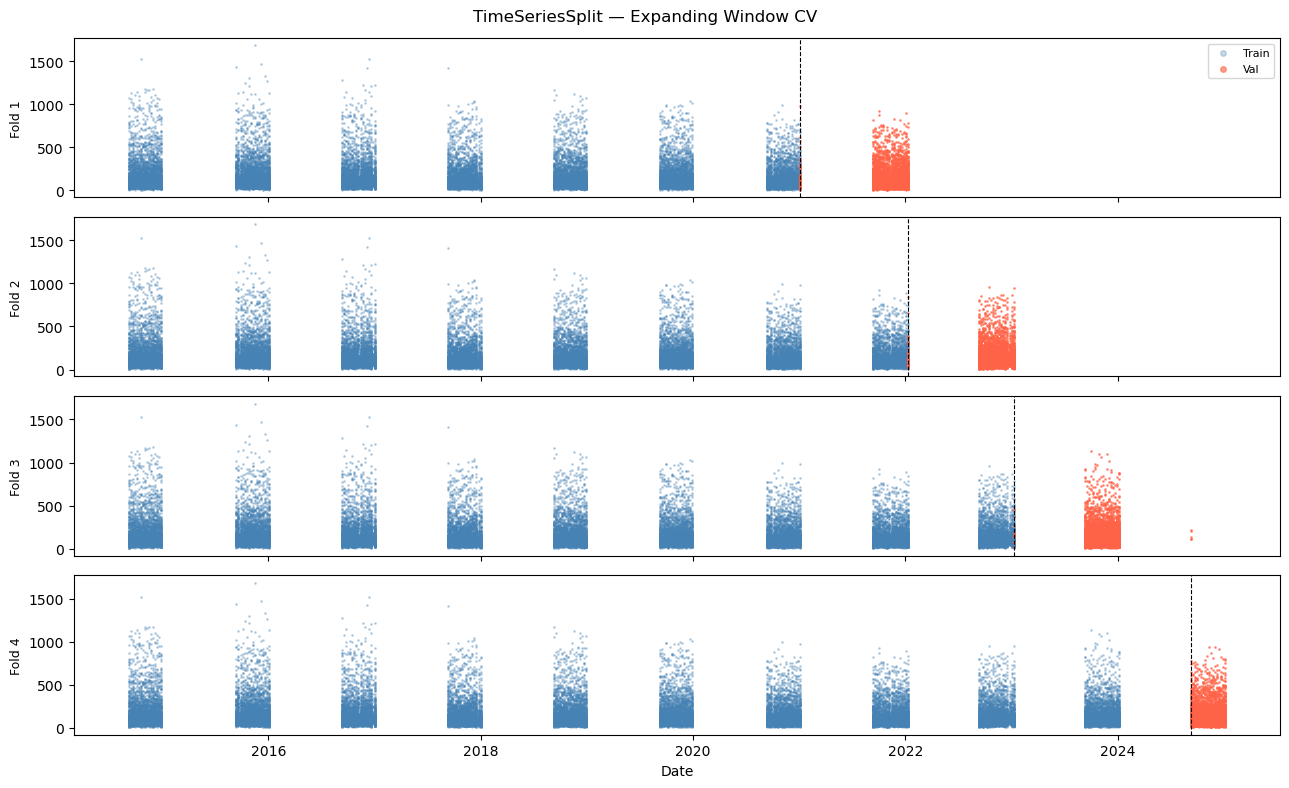

  Fold 1: train=26,148  val=4,100  train_end_idx=26147
  Fold 2: train=30,248  val=4,100  train_end_idx=30247
  Fold 3: train=34,348  val=4,100  train_end_idx=34347
  Fold 4: train=38,448  val=4,100  train_end_idx=38447


In [13]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)

fig, axes = plt.subplots(N_SPLITS, 1, figsize=(13, 8), sharex=True)
for fold, (tr_idx, val_idx) in enumerate(tscv.split(df)):
    ax = axes[fold]
    train_dates = df.iloc[tr_idx]["Date"]
    val_dates   = df.iloc[val_idx]["Date"]
    ax.scatter(train_dates, df[TARGET_COL].values[tr_idx],  s=1, color="steelblue", alpha=0.3, label="Train")
    ax.scatter(val_dates,   df[TARGET_COL].values[val_idx], s=1, color="tomato",    alpha=0.6, label="Val")
    ax.axvline(val_dates.min(), color="black", ls="--", linewidth=0.8)
    ax.set_ylabel(f"Fold {fold+1}", fontsize=9)
    if fold == 0:
        ax.legend(markerscale=4, fontsize=8)

axes[-1].set_xlabel("Date")
fig.suptitle("TimeSeriesSplit — Expanding Window CV", fontsize=12)
plt.tight_layout()
plt.show()

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_enc)):
    print(f"  Fold {fold+1}: train={len(tr_idx):,}  val={len(val_idx):,}  "
          f"train_end_idx={tr_idx[-1]}")

## 4. Optuna Phase 1:  Wide Search (300 Trials)

Wide hyperparameter bounds; `MedianPruner` kills unpromising trials after fold 1 or 2.


In [14]:
def _lgbm_cv_r2(params, X, y, tscv, cat_cols, trial=None):
    """Run CV with given params; return (fold_r2s, oof_preds, best_iters).
    If trial is provided, reports intermediate values for Optuna pruning.
    """
    n = len(y)
    oof_preds = np.full(n, np.nan)
    best_iters = []
    fold_r2s   = []

    for fold_num, (tr_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr,  X_val  = X.iloc[tr_idx],       X.iloc[val_idx]
        y_tr,  y_val  = y[tr_idx],             y[val_idx]

        dtrain = lgb.Dataset(X_tr, label=y_tr,   categorical_feature=cat_cols, free_raw_data=False)
        dval   = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_cols,
                             reference=dtrain, free_raw_data=False)

        callbacks = [
            lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(0),
        ]
        booster = lgb.train(
            params, dtrain,
            num_boost_round=NUM_BOOST_ROUND,
            valid_sets=[dval],
            callbacks=callbacks,
        )

        preds = booster.predict(X_val)
        oof_preds[val_idx] = preds
        best_iters.append(booster.best_iteration)

        r2 = r2_score(y_val, preds)
        fold_r2s.append(r2)

        if trial is not None:
            trial.report(float(np.mean(fold_r2s)), fold_num)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    return fold_r2s, oof_preds, best_iters


BASE_PARAMS = {
    'objective': 'regression',
    'metric': 'rmse',
    'num_threads': NUM_THREADS,
    'verbosity': -1,
}


def phase1_objective(trial):
    # Sample max_depth first; num_leaves is constrained to stay below 2^max_depth
    # per LightGBM docs: num_leaves should be < 2^max_depth to avoid overfitting
    max_depth      = trial.suggest_int('max_depth', 4, 9)
    num_leaves_max = max((2 ** max_depth) - 2, 10)
    num_leaves     = trial.suggest_int('num_leaves', 4, num_leaves_max, step=2)

    params = {
        **BASE_PARAMS,
        'max_depth':          max_depth,
        'num_leaves':         num_leaves,
        'learning_rate':      trial.suggest_float('learning_rate',      0.03, 0.20,  log=False),
        'min_child_samples':  trial.suggest_int  ('min_child_samples',  10,    150),
        'feature_fraction':   trial.suggest_float('feature_fraction',   0.58,   1.0),
        'bagging_fraction':   trial.suggest_float('bagging_fraction',   0.58,   1.0),
        'bagging_freq':       trial.suggest_int  ('bagging_freq',       1,     10),
        'reg_alpha':          trial.suggest_float('reg_alpha',          1e-2,  6.0,  log=False),
        'reg_lambda':         trial.suggest_float('reg_lambda',         1e-2,  6.0,  log=False),
        'min_split_gain':     trial.suggest_float('min_split_gain',     0.0,   3.0),
        # Categorical-specific: important when cardinality varies (Market=56, at/ht=32)
        'min_data_per_group': trial.suggest_int  ('min_data_per_group', 10,    200),
        'cat_smooth':         trial.suggest_float('cat_smooth',         1.0,  100.0, log=True),
    }
    fold_r2s, _, _ = _lgbm_cv_r2(params, X_enc, y, tscv, cat_cols_sanitized, trial=trial)
    return float(np.mean(fold_r2s))


print("Phase 1 objective defined.")


Phase 1 objective defined.


In [15]:
try_params = {
"max_depth": 5,
"num_leaves": 24,
"learning_rate": 0.03143774585946837,
"min_child_samples": 45,
"feature_fraction": 0.595121635759519,
"bagging_fraction": 0.7497845321983468,
"bagging_freq": 2,
"reg_alpha": 3.8958413675182886,
"reg_lambda": 1.1925574400204104,
"min_split_gain": 1.7745810843681873,
"min_data_per_group": 67,
"cat_smooth": 12.141802124095566
}

In [16]:
def _log_best(study, trial):
    if study.best_trial.number == trial.number:
        print(f"\n[Trial {trial.number}] New best R²: {trial.value:.5f}")
        for k, v in trial.params.items():
            print(f"  {k}: {v}")

study1 = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
    study_name='lgbm_nfl_phase1',
)

study1.enqueue_trial(try_params)  # seed with training round 1 best

study1.optimize(phase1_objective, n_trials=250, n_jobs=1,
                show_progress_bar=True, callbacks=[_log_best])

print(f"\nPhase 1 complete — {len(study1.trials)} trials")
print(f"Best R²: {study1.best_value:.5f}")
print("Best params:")
for k, v in study1.best_params.items():
    print(f"  {k}: {v}")


  0%|          | 0/250 [00:00<?, ?it/s]


[Trial 0] New best R²: 0.91448
  max_depth: 5
  num_leaves: 24
  learning_rate: 0.03143774585946837
  min_child_samples: 45
  feature_fraction: 0.595121635759519
  bagging_fraction: 0.7497845321983468
  bagging_freq: 2
  reg_alpha: 3.8958413675182886
  reg_lambda: 1.1925574400204104
  min_split_gain: 1.7745810843681873
  min_data_per_group: 67
  cat_smooth: 12.141802124095566

Phase 1 complete — 250 trials
Best R²: 0.91448
Best params:
  max_depth: 5
  num_leaves: 24
  learning_rate: 0.03143774585946837
  min_child_samples: 45
  feature_fraction: 0.595121635759519
  bagging_fraction: 0.7497845321983468
  bagging_freq: 2
  reg_alpha: 3.8958413675182886
  reg_lambda: 1.1925574400204104
  min_split_gain: 1.7745810843681873
  min_data_per_group: 67
  cat_smooth: 12.141802124095566


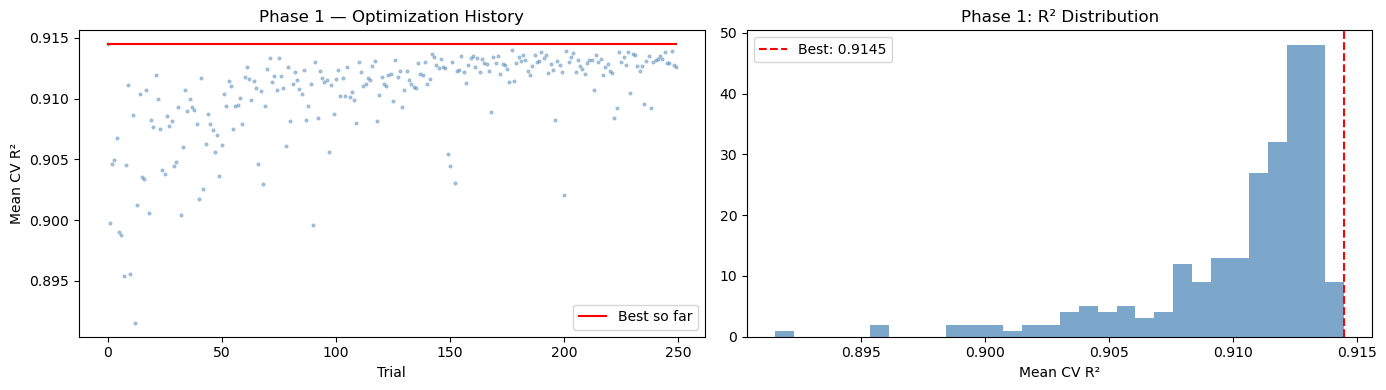

Pruned: 0  |  Completed: 250


In [17]:
# Phase 1 trial history
trials_df1 = study1.trials_dataframe()
completed1 = trials_df1[trials_df1['state'] == 'COMPLETE']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Optimization history
axes[0].plot(completed1['number'], completed1['value'], '.', alpha=0.4, markersize=4, color='steelblue')
best_so_far = completed1['value'].cummax()
axes[0].plot(completed1['number'], best_so_far, 'r-', linewidth=1.5, label='Best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Mean CV R²')
axes[0].set_title('Phase 1 — Optimization History')
axes[0].legend()

# R² distribution
axes[1].hist(completed1['value'].dropna(), bins=30, color='steelblue', alpha=0.7)
axes[1].axvline(study1.best_value, color='red', linestyle='--', label=f'Best: {study1.best_value:.4f}')
axes[1].set_xlabel('Mean CV R²')
axes[1].set_title('Phase 1: R² Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Pruned: {(trials_df1['state'] == 'PRUNED').sum()}  |  Completed: {len(completed1)}")


## 5. Optuna Phase 2:  Refined Search (200 Trials)

Narrow bounds centered on Phase 1 best. Continues from the same study object to retain TPE history.


In [18]:
def phase2_objective(trial):
    b = study1.best_params

    # max_depth: ±1 around Phase 1 best; recompute num_leaves ceiling from new depth
    max_depth = trial.suggest_int(
        'max_depth',
        max(3,  b['max_depth'] - 1),
        min(10, b['max_depth'] + 1),
    )
    num_leaves_max = max((2 ** max_depth) - 2, 10)
    num_leaves_lo  = max(4, b['num_leaves'] - 20)
    num_leaves_hi  = min(num_leaves_max, b['num_leaves'] + 20)
    if num_leaves_lo >= num_leaves_hi:
        num_leaves_lo = max(4, num_leaves_hi - 4)
    num_leaves = trial.suggest_int('num_leaves', num_leaves_lo, num_leaves_hi, step=2)

    params = {
        **BASE_PARAMS,
        'max_depth':   max_depth,
        'num_leaves':  num_leaves,
        'learning_rate': trial.suggest_float(
            'learning_rate',
            b['learning_rate'] * 0.7,
            b['learning_rate'] * 2.0,
            log=False,
        ),
        'min_child_samples': trial.suggest_int(
            'min_child_samples',
            max(5,   b['min_child_samples'] - 30),
            min(200, b['min_child_samples'] + 30),
        ),
        'feature_fraction': trial.suggest_float(
            'feature_fraction',
            max(0.5, b['feature_fraction'] - 0.15),
            min(1.0, b['feature_fraction'] + 0.15),
        ),
        'bagging_fraction': trial.suggest_float(
            'bagging_fraction',
            max(0.5, b['bagging_fraction'] - 0.15),
            min(1.0, b['bagging_fraction'] + 0.15),
        ),
        'bagging_freq': trial.suggest_int(
            'bagging_freq',
            max(1,  b['bagging_freq'] - 2),
            min(10, b['bagging_freq'] + 2),
        ),
        'reg_alpha': trial.suggest_float(
            'reg_alpha',
            max(1e-3, b['reg_alpha'] * 0.5),
            min(10.0, b['reg_alpha'] * 2.0),
            log=False,
        ),
        'reg_lambda': trial.suggest_float(
            'reg_lambda',
            max(1e-3, b['reg_lambda'] * 0.5),
            min(10.0, b['reg_lambda'] * 2.0),
            log=False,
        ),
        'min_split_gain': trial.suggest_float(
            'min_split_gain',
            max(0.0, b['min_split_gain'] - 0.5),
            min(4.0, b['min_split_gain'] + 0.5),
        ),
        'min_data_per_group': trial.suggest_int(
            'min_data_per_group',
            max(5,   b['min_data_per_group'] - 50),
            min(300, b['min_data_per_group'] + 50),
        ),
        'cat_smooth': trial.suggest_float(
            'cat_smooth',
            max(1.0, b['cat_smooth'] * 0.25),
            min(200.0, b['cat_smooth'] * 4.0),
            log=False,
        ),
    }
    fold_r2s, _, _ = _lgbm_cv_r2(params, X_enc, y, tscv, cat_cols_sanitized, trial=trial)
    return float(np.mean(fold_r2s))


print("Phase 2 objective defined.")


Phase 2 objective defined.


In [19]:
study2 = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=99),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
    study_name='lgbm_nfl_phase2',
)

study2.enqueue_trial(study1.best_params)  # seed with phase 1 best

study2.optimize(phase2_objective, n_trials=200, n_jobs=1,
                show_progress_bar=True, callbacks=[_log_best])

print(f"\nPhase 2 complete — {len(study2.trials)} trials")
print(f"Best R²: {study2.best_value:.5f}")
print("Best params:")
for k, v in study2.best_params.items():
    print(f"  {k}: {v}")

best_params = {**BASE_PARAMS, **study2.best_params}
overall_best_r2 = max(study1.best_value, study2.best_value)
print(f"\nOverall best CV R² (Phase 1 + 2): {overall_best_r2:.5f}")

# Use whichever phase yielded the best result
if study1.best_value > study2.best_value:
    print("  (Using Phase 1 best params — Phase 1 outperformed Phase 2)")
    best_params = {**BASE_PARAMS, **study1.best_params}


  0%|          | 0/200 [00:00<?, ?it/s]


[Trial 0] New best R²: 0.91448
  max_depth: 5
  num_leaves: 24
  learning_rate: 0.03143774585946837
  min_child_samples: 45
  feature_fraction: 0.595121635759519
  bagging_fraction: 0.7497845321983468
  bagging_freq: 2
  reg_alpha: 3.8958413675182886
  reg_lambda: 1.1925574400204104
  min_split_gain: 1.7745810843681873
  min_data_per_group: 67
  cat_smooth: 12.141802124095566

[Trial 122] New best R²: 0.91455
  max_depth: 5
  num_leaves: 24
  learning_rate: 0.030649967629056512
  min_child_samples: 52
  feature_fraction: 0.5642428504219578
  bagging_fraction: 0.8001773022031519
  bagging_freq: 2
  reg_alpha: 3.903425132486366
  reg_lambda: 1.2384200340475784
  min_split_gain: 1.5349977581307082
  min_data_per_group: 46
  cat_smooth: 19.827388610916774

[Trial 156] New best R²: 0.91457
  max_depth: 5
  num_leaves: 28
  learning_rate: 0.0289928393736182
  min_child_samples: 47
  feature_fraction: 0.562005212833755
  bagging_fraction: 0.7918475443338095
  bagging_freq: 2
  reg_alpha: 4.6

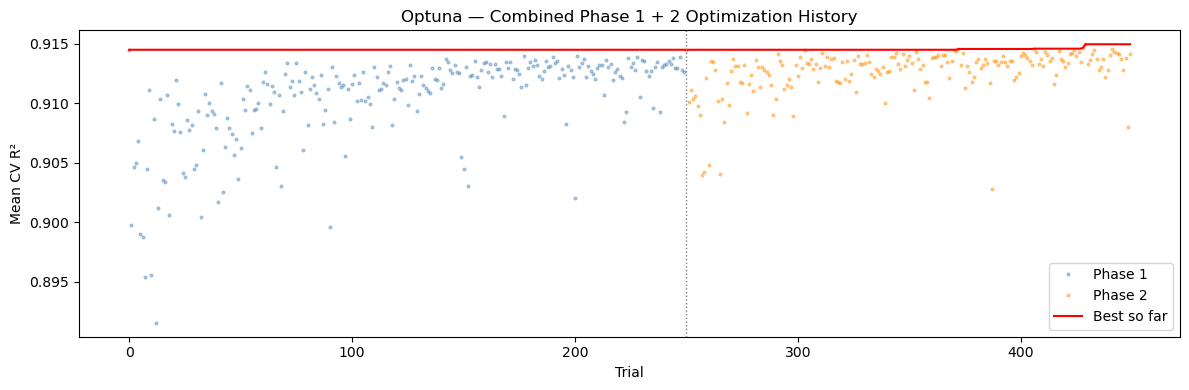

In [20]:
# Combined optimization history
trials_df2 = study2.trials_dataframe()
completed2 = trials_df2[trials_df2['state'] == 'COMPLETE']

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(completed1['number'], completed1['value'], '.', alpha=0.4, markersize=4,
        color='steelblue', label='Phase 1')
ax.plot(completed2['number'] + len(completed1), completed2['value'], '.', alpha=0.4, markersize=4,
        color='darkorange', label='Phase 2')
best_all = pd.concat([completed1['value'], completed2['value']]).cummax()
ax.plot(range(len(best_all)), best_all.values, 'r-', linewidth=1.5, label='Best so far')
ax.axvline(len(completed1), color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Trial')
ax.set_ylabel('Mean CV R²')
ax.set_title('Optuna — Combined Phase 1 + 2 Optimization History')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Final Model Training

Step 1: re-run CV with best params to collect OOF predictions and average `best_iteration` across folds.  
Step 2: train one final model on the full dataset using those params and the averaged iteration count.


In [21]:
print("Running final CV with best params (collects OOF predictions)...")

fold_r2s_final, oof_preds, best_iters = _lgbm_cv_r2(
    best_params, X_enc, y, tscv, cat_cols_sanitized, trial=None
)

# Re-run with verbose logging to show fold-level detail
print("\nFold-level results:")
for fold_num, (tr_idx, val_idx) in enumerate(tscv.split(X_enc)):
    print(f"  Fold {fold_num+1}: R²={fold_r2s_final[fold_num]:.4f}  "
          f"best_iter={best_iters[fold_num]}")

avg_best_iter = int(np.round(np.mean(best_iters)))
mean_oof_r2   = np.mean(fold_r2s_final)
print(f"\nMean OOF R²: {mean_oof_r2:.5f}")
print(f"Avg best_iteration: {avg_best_iter}")


Running final CV with best params (collects OOF predictions)...

Fold-level results:
  Fold 1: R²=0.9143  best_iter=3104
  Fold 2: R²=0.9244  best_iter=3459
  Fold 3: R²=0.9144  best_iter=3309
  Fold 4: R²=0.9066  best_iter=3500

Mean OOF R²: 0.91494
Avg best_iteration: 3343


In [22]:
# Build OOF DataFrame (only rows covered by at least one validation fold)
oof_mask = ~np.isnan(oof_preds)
oof_df = df_meta.loc[oof_mask].copy().reset_index(drop=True)
oof_df['y_true'] = y[oof_mask]
oof_df['y_pred'] = oof_preds[oof_mask]

print(f"OOF rows: {len(oof_df):,} of {len(df):,}")

# Train final model on ALL data
print("\nTraining final model on full dataset...")
dtrain_full = lgb.Dataset(X_enc, label=y,
                          categorical_feature=cat_cols_sanitized,
                          free_raw_data=False)

final_params = {**best_params, 'num_threads': NUM_THREADS, 'verbosity': -1}
final_model = lgb.train(
    final_params,
    dtrain_full,
    num_boost_round=avg_best_iter,
)
print(f"Final model trained with {avg_best_iter} boosting rounds.")


OOF rows: 16,400 of 42,548

Training final model on full dataset...
Final model trained with 3343 boosting rounds.


## 7. Model Evaluation

All R² metrics are computed on OOF predictions (unbiased, never seen during training).  
Subset R² uses the subgroup's own mean as the baseline (standard `r2_score`).


══════════════════════════════════════════════════
  LightGBM OOF R²   : 0.9152
  LightGBM OOF RMSE : 38.74
══════════════════════════════════════════════════

Baseline comparison:
  Ridge (Linear) : ~0.913
  MLP (OHE)      : ~0.908
  MLP (Embeddings): ~0.902
  LightGBM       : 0.9152  
  Val R²        : 0.9152  (raw scale)
  Val R² (log)  : 0.8625  (log1p scale)
  Val RMSE      : 38.74


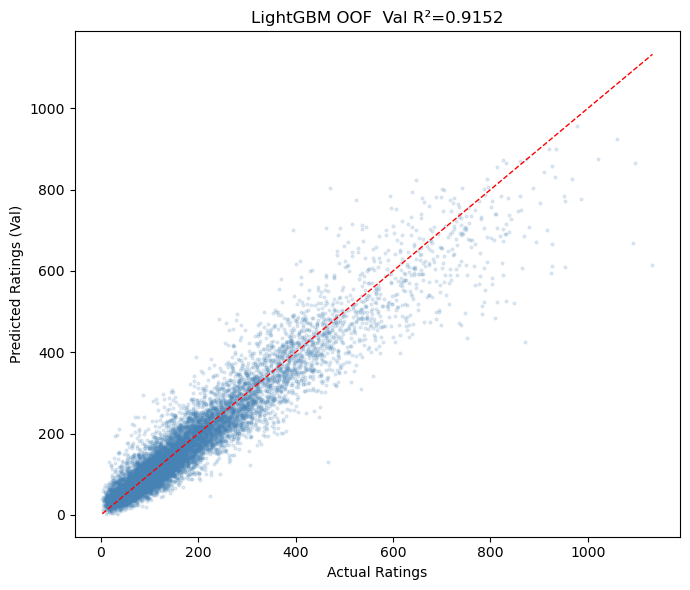

In [23]:
overall_r2 = r2_score(oof_df['y_true'], oof_df['y_pred'])
overall_rmse = np.sqrt(np.mean((oof_df['y_true'] - oof_df['y_pred'])**2))

print("═" * 50)
print(f"  LightGBM OOF R²   : {overall_r2:.4f}")
print(f"  LightGBM OOF RMSE : {overall_rmse:.2f}")
print("═" * 50)
print()
print("Baseline comparison:")
print(f"  Ridge (Linear) : ~0.913")
print(f"  MLP (OHE)      : ~0.908")
print(f"  MLP (Embeddings): ~0.902")
print(f"  LightGBM       : {overall_r2:.4f}  {'<-- BEAT BASELINE!' if overall_r2 > 0.92 else ''}")

plot_actual_vs_predicted(oof_df['y_true'].values, oof_df['y_pred'].values, title='LightGBM OOF')


In [24]:
def compute_subset_r2(oof_df, group_col):
    rows = []
    for name, grp in oof_df.groupby(group_col):
        rows.append({
            'group': name,
            'r2': r2_score(grp['y_true'], grp['y_pred']),
            'n': len(grp),
        })
    return pd.DataFrame(rows).sort_values('r2', ascending=True)



print("Subset R² helper defined.")


Subset R² helper defined.


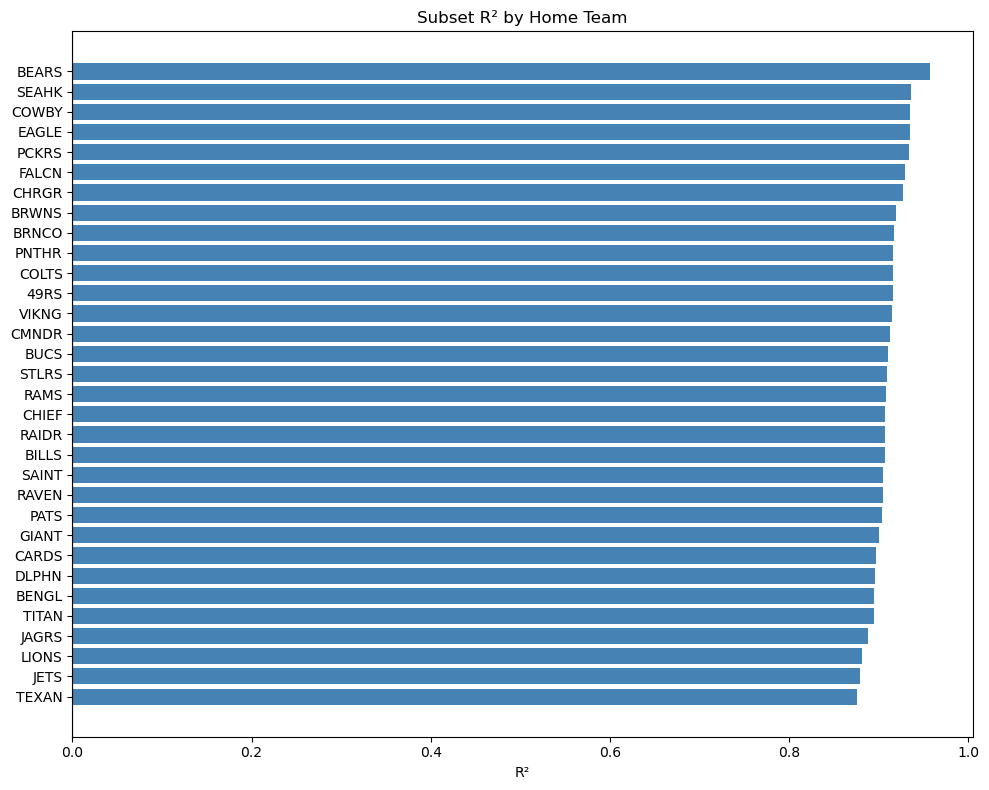

Median R² by team: 0.9091
Worst team: TEXAN  R²=0.8753
Best team:  BEARS  R²=0.9571


In [25]:
# R² by home team
plot_subset_r2(oof_df['y_true'].values, oof_df['y_pred'].values, oof_df['ht'].values,
               title='Subset R² by Home Team')
r2_ht = compute_subset_r2(oof_df, 'ht')
print(f"Median R² by team: {r2_ht['r2'].median():.4f}")
print(f"Worst team: {r2_ht.iloc[0]['group']}  R²={r2_ht.iloc[0]['r2']:.4f}")
print(f"Best team:  {r2_ht.iloc[-1]['group']}  R²={r2_ht.iloc[-1]['r2']:.4f}")

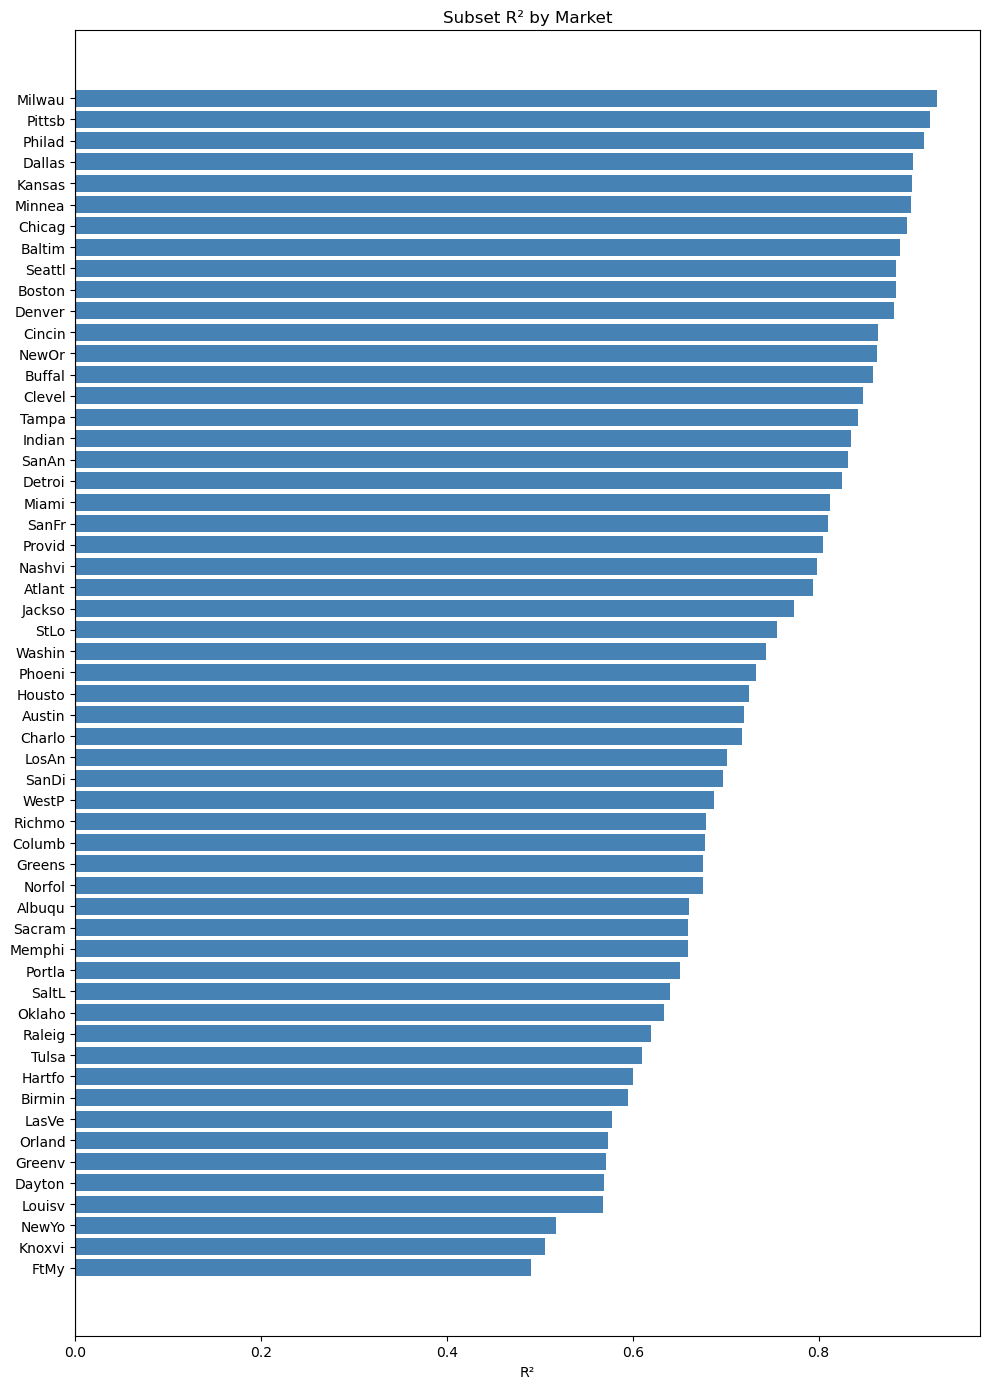

Median R² by market: 0.7289


In [26]:
# R² by market
plot_subset_r2(oof_df['y_true'].values, oof_df['y_pred'].values, oof_df['Market_abrev'].values,
               title='Subset R² by Market', figsize=(10, 14))
r2_mkt = compute_subset_r2(oof_df, 'Market_abrev')
print(f"Median R² by market: {r2_mkt['r2'].median():.4f}")

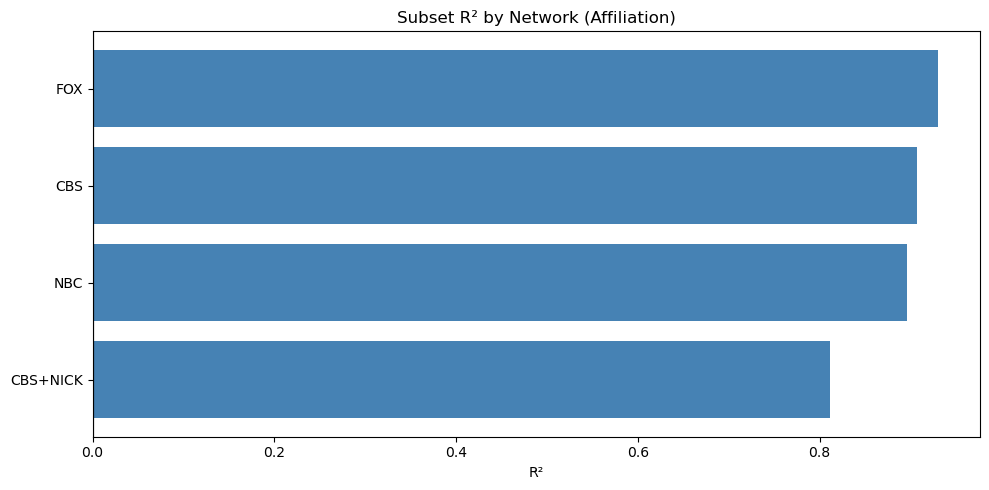

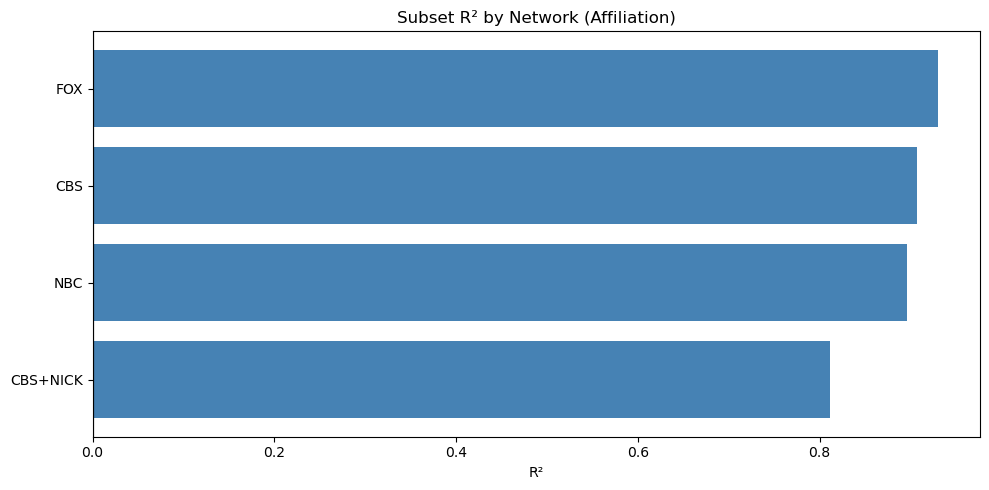

In [27]:
# R² by network
plot_subset_r2(oof_df['y_true'].values, oof_df['y_pred'].values, oof_df['Affiliation'].values,
               title='Subset R² by Network (Affiliation)', figsize=(10, 5))

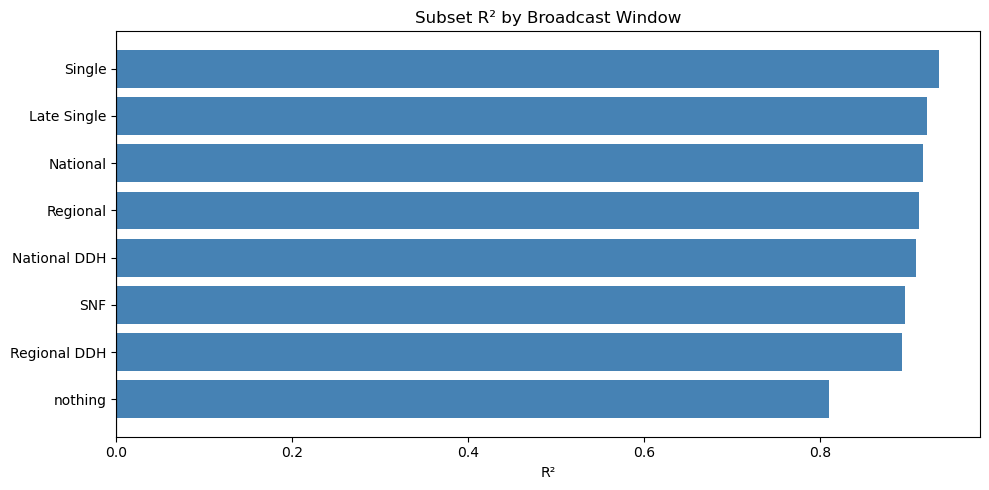

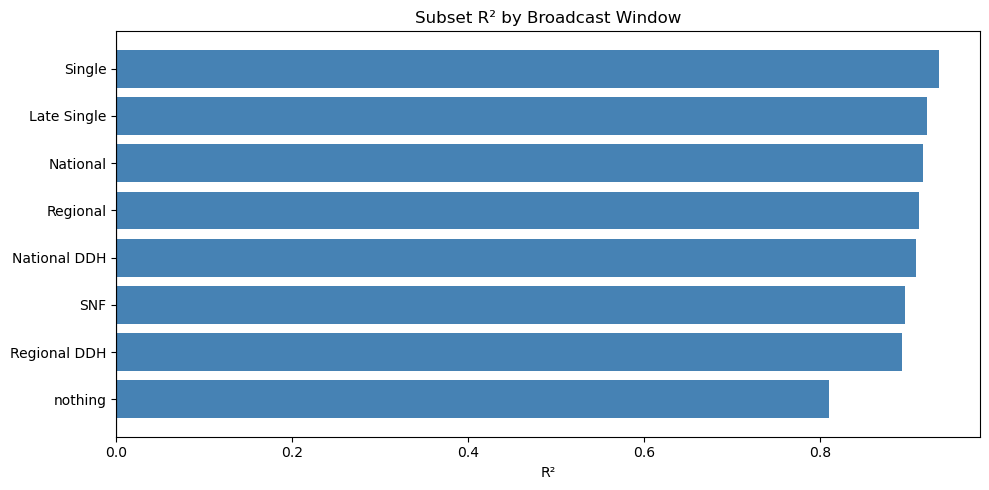

In [28]:
# R² by window
plot_subset_r2(oof_df['y_true'].values, oof_df['y_pred'].values, oof_df['window'].values,
               title='Subset R² by Broadcast Window', figsize=(10, 5))

## 8. Model Interpretation

All model interpretations use the final model trained on the full dataset (higher signal, no fold boundary artifacts).


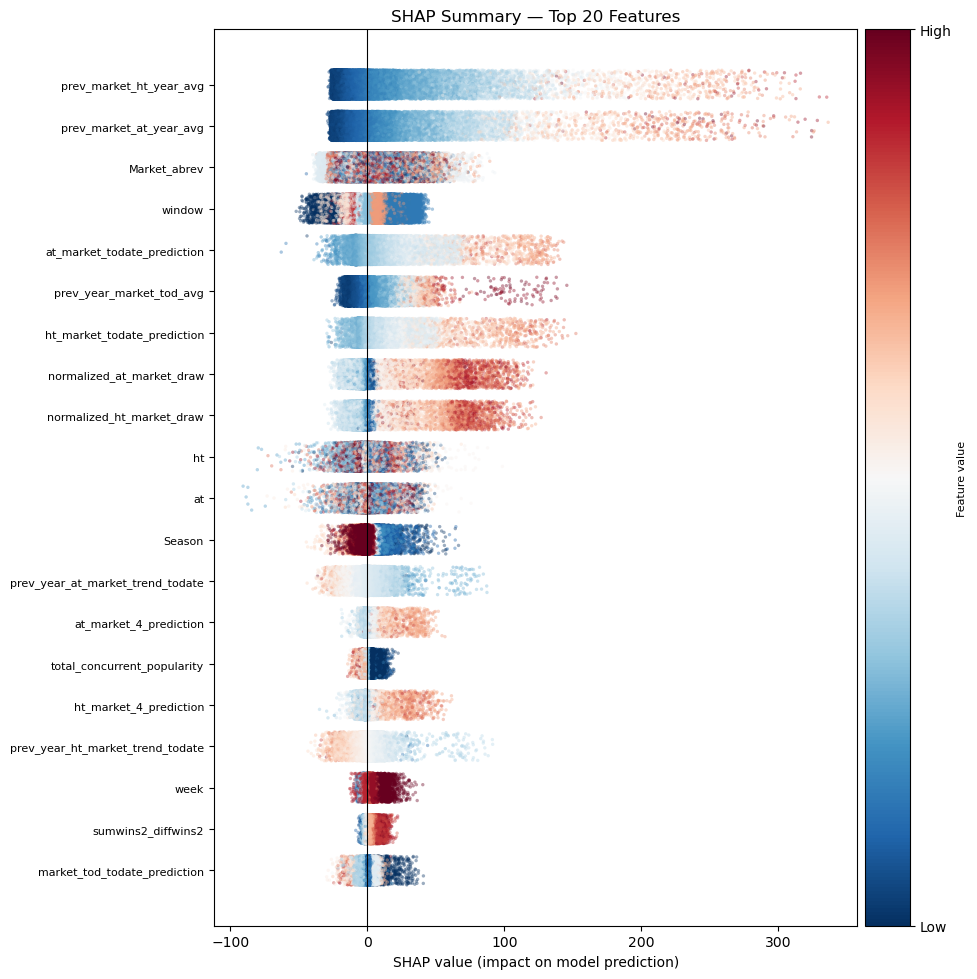

'Note that LightGBM uses numerical encoded codes for categorical features, therefore the coloration on the categorical features here should not \nbe interpereted directly'

In [29]:
# SHAP summary beeswarm (uses full X_enc for density)
shap_vals, feat_names = generate_shap_summary_lgbm_fast(final_model, X_enc, max_display=20)

'''Note that LightGBM uses numerical encoded codes for categorical features, therefore the coloration on the categorical features here should not 
be interpereted directly'''


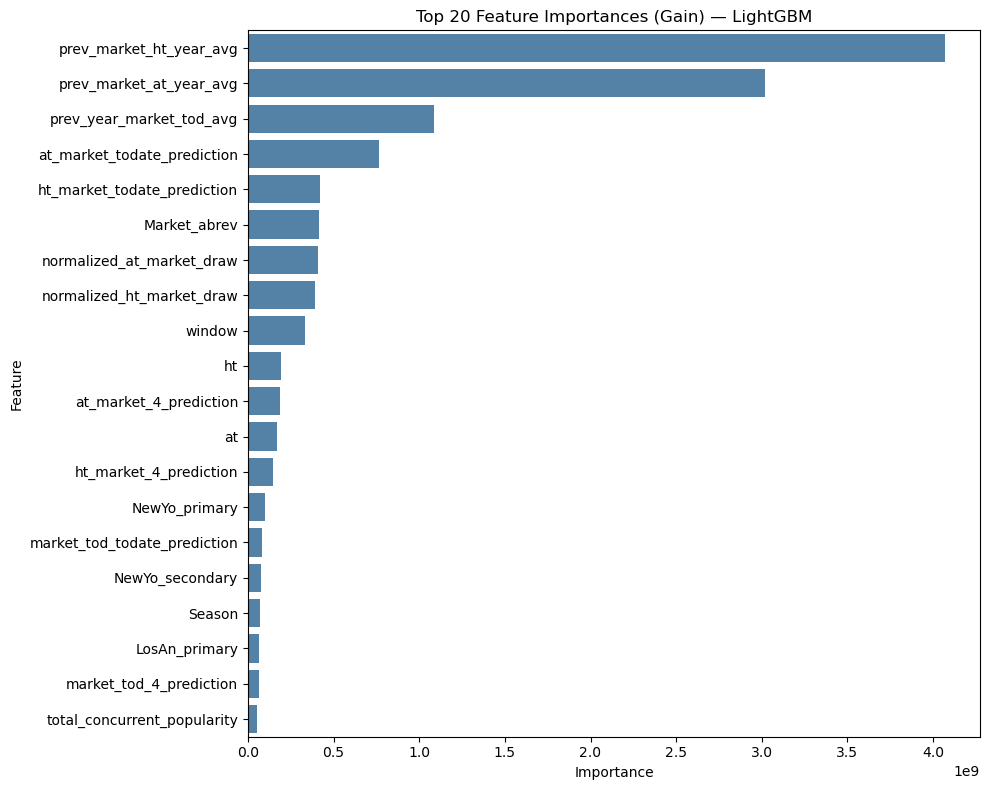

                    Feature   Importance
    prev_market_ht_year_avg 4.070505e+09
    prev_market_at_year_avg 3.019080e+09
   prev_year_market_tod_avg 1.088718e+09
at_market_todate_prediction 7.634075e+08
ht_market_todate_prediction 4.228624e+08
               Market_abrev 4.143889e+08
  normalized_at_market_draw 4.110503e+08
  normalized_ht_market_draw 3.931133e+08
                     window 3.329997e+08
                         ht 1.927227e+08


In [30]:
# Gain-based feature importance
imp_df = feature_importance_plot(final_model, top_n=20, importance_type='gain', return_df=True)
print(imp_df.head(10).to_string(index=False))


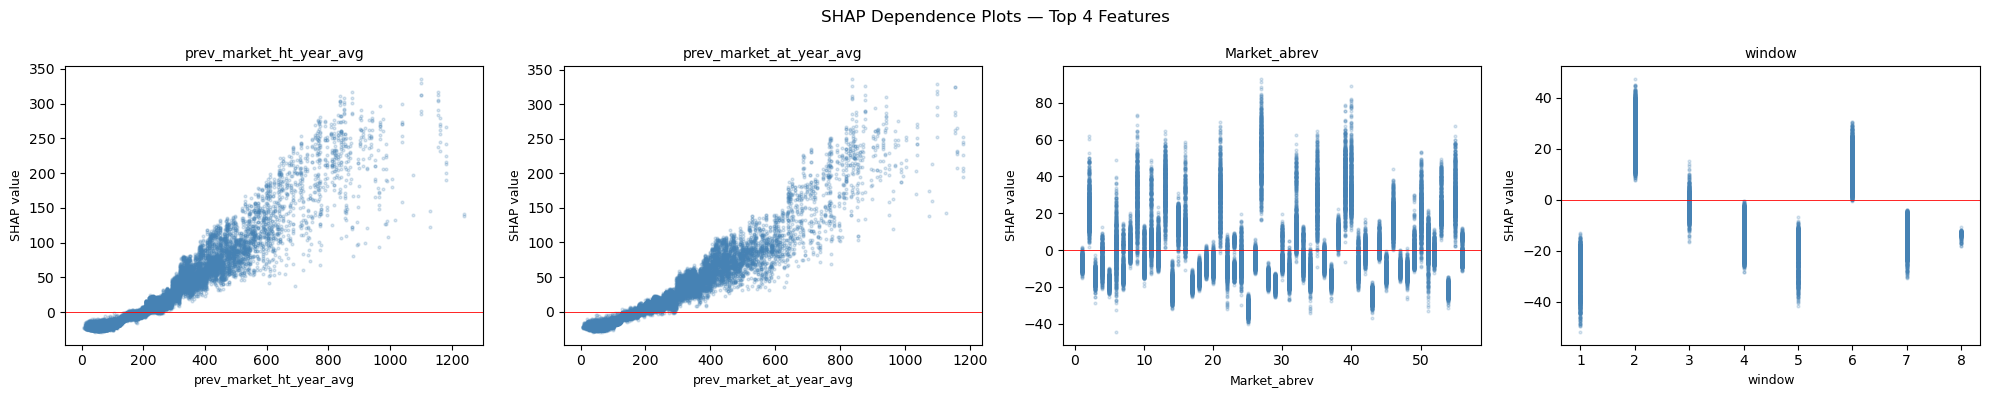

In [31]:
# SHAP dependence plots - top 4 features by mean |SHAP|
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
top4_idx  = np.argsort(mean_abs_shap)[::-1][:4]
top4_names = [feat_names[i] for i in top4_idx]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, idx, name in zip(axes, top4_idx, top4_names):
    x_vals  = X_enc.iloc[:, idx].values.astype(float)
    shp_col = shap_vals[:, idx]
    valid   = ~np.isnan(x_vals)
    ax.scatter(x_vals[valid], shp_col[valid], alpha=0.2, s=4, color='steelblue')
    ax.axhline(0, color='red', linewidth=0.6)
    ax.set_xlabel(name, fontsize=9)
    ax.set_ylabel('SHAP value', fontsize=9)
    ax.set_title(name, fontsize=10)
plt.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=12)
plt.tight_layout()
plt.show()


Heatmap shape: (32, 56)  (teams × markets)
NaN cells (team-market pairs never observed): 0


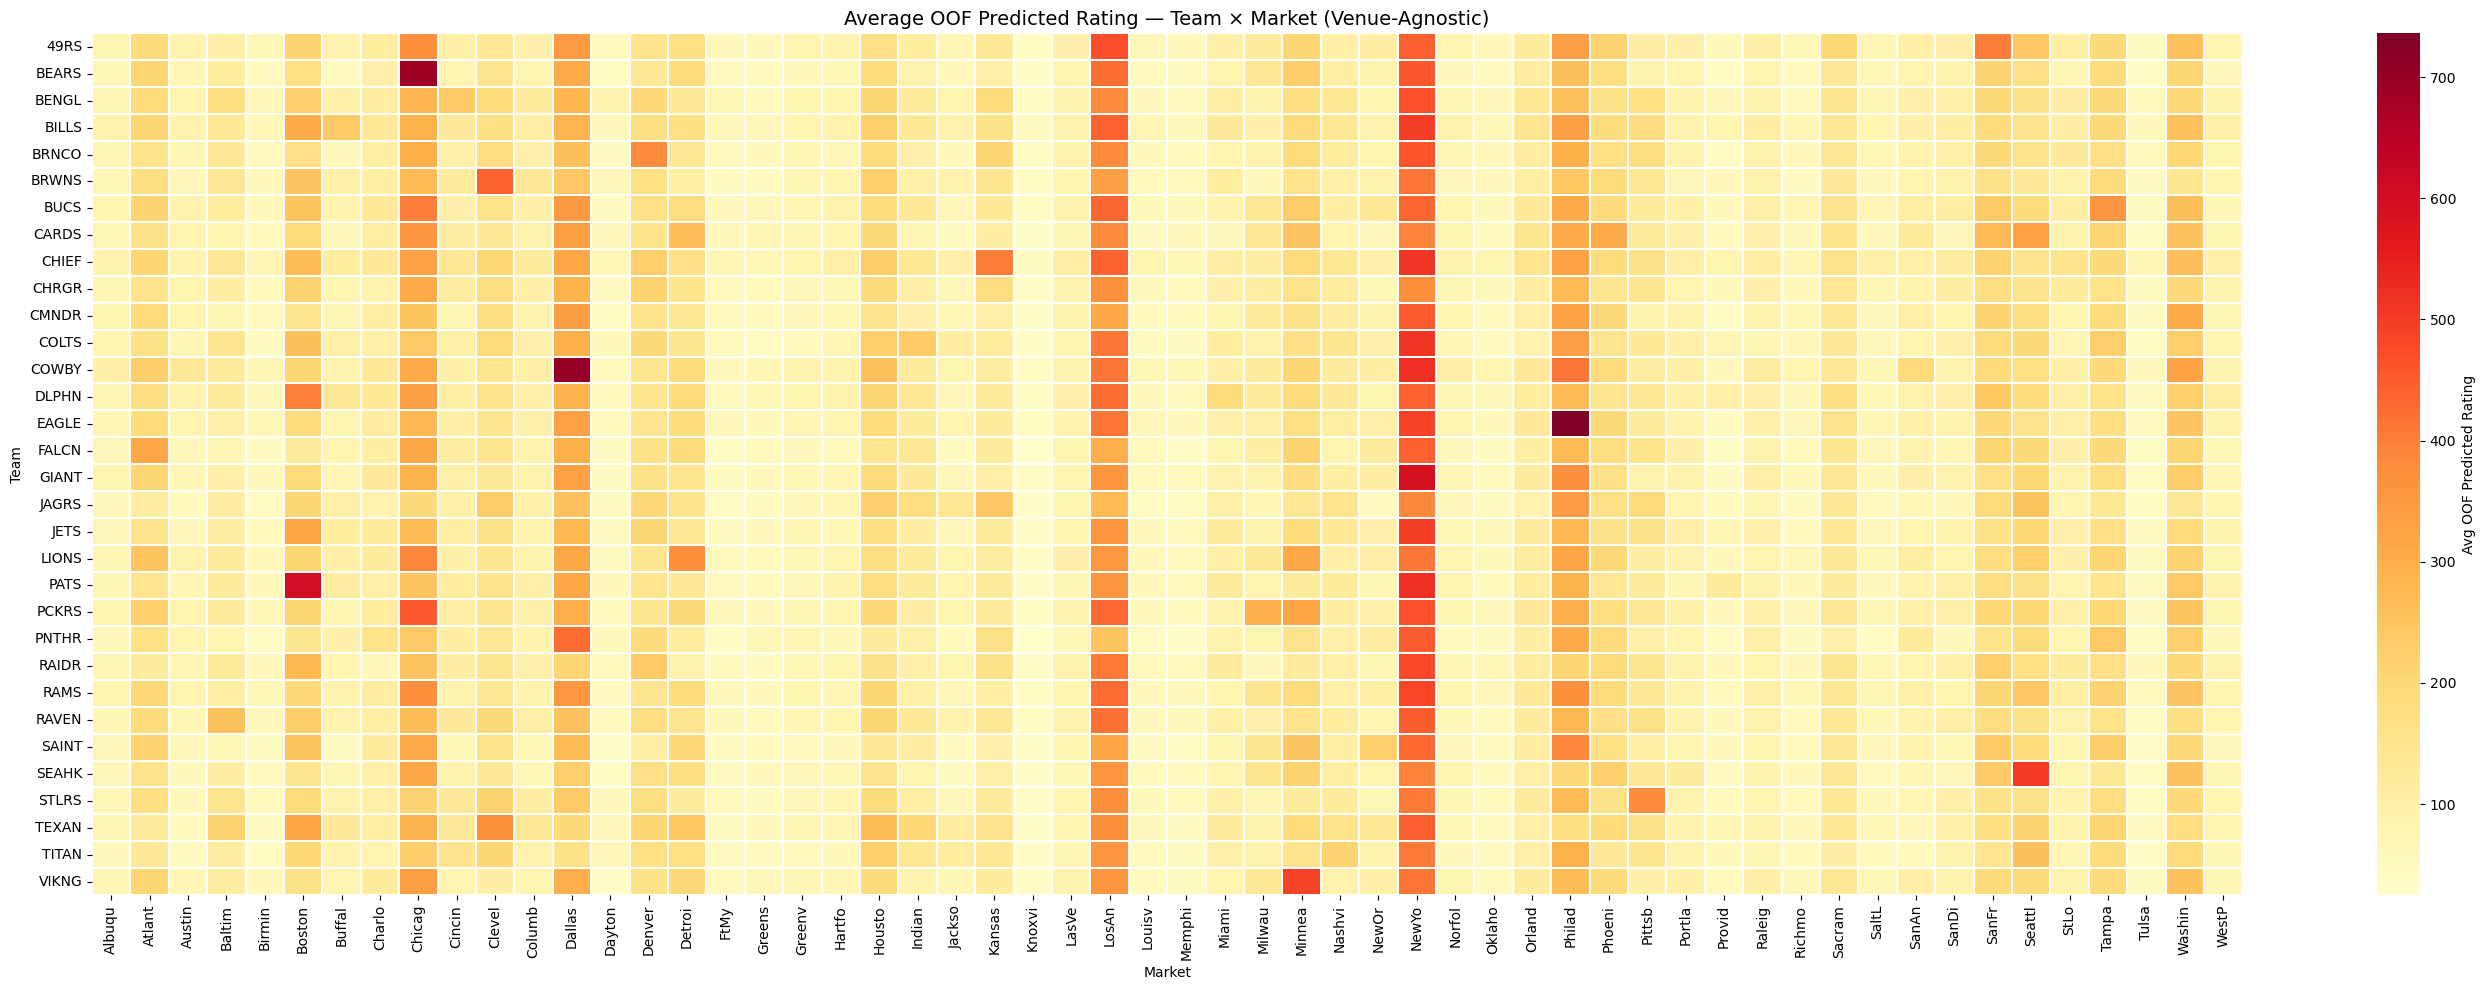

In [32]:
# 32×56 Team × Market OOF prediction heatmap (venue-agnostic)
home_rows = oof_df[['ht', 'Market_abrev', 'y_pred']].rename(columns={'ht': 'team'})
away_rows = oof_df[['at', 'Market_abrev', 'y_pred']].rename(columns={'at': 'team'})

team_market_matrix = (
    pd.concat([home_rows, away_rows])
      .groupby(['team', 'Market_abrev'])['y_pred']
      .mean()
      .unstack('Market_abrev')
)

print(f"Heatmap shape: {team_market_matrix.shape}  (teams × markets)")
print(f"NaN cells (team-market pairs never observed): {team_market_matrix.isna().sum().sum()}")

fig, ax = plt.subplots(figsize=(28, 10))
sns.heatmap(
    team_market_matrix,
    cmap='YlOrRd', ax=ax,
    annot=False,
    linewidths=0.2, linecolor='white',
    cbar_kws={'label': 'Avg OOF Predicted Rating'},
)
ax.set_title('Average OOF Predicted Rating — Team × Market (Venue-Agnostic)', fontsize=14)
ax.set_xlabel('Market')
ax.set_ylabel('Team')
plt.tight_layout()
plt.show()


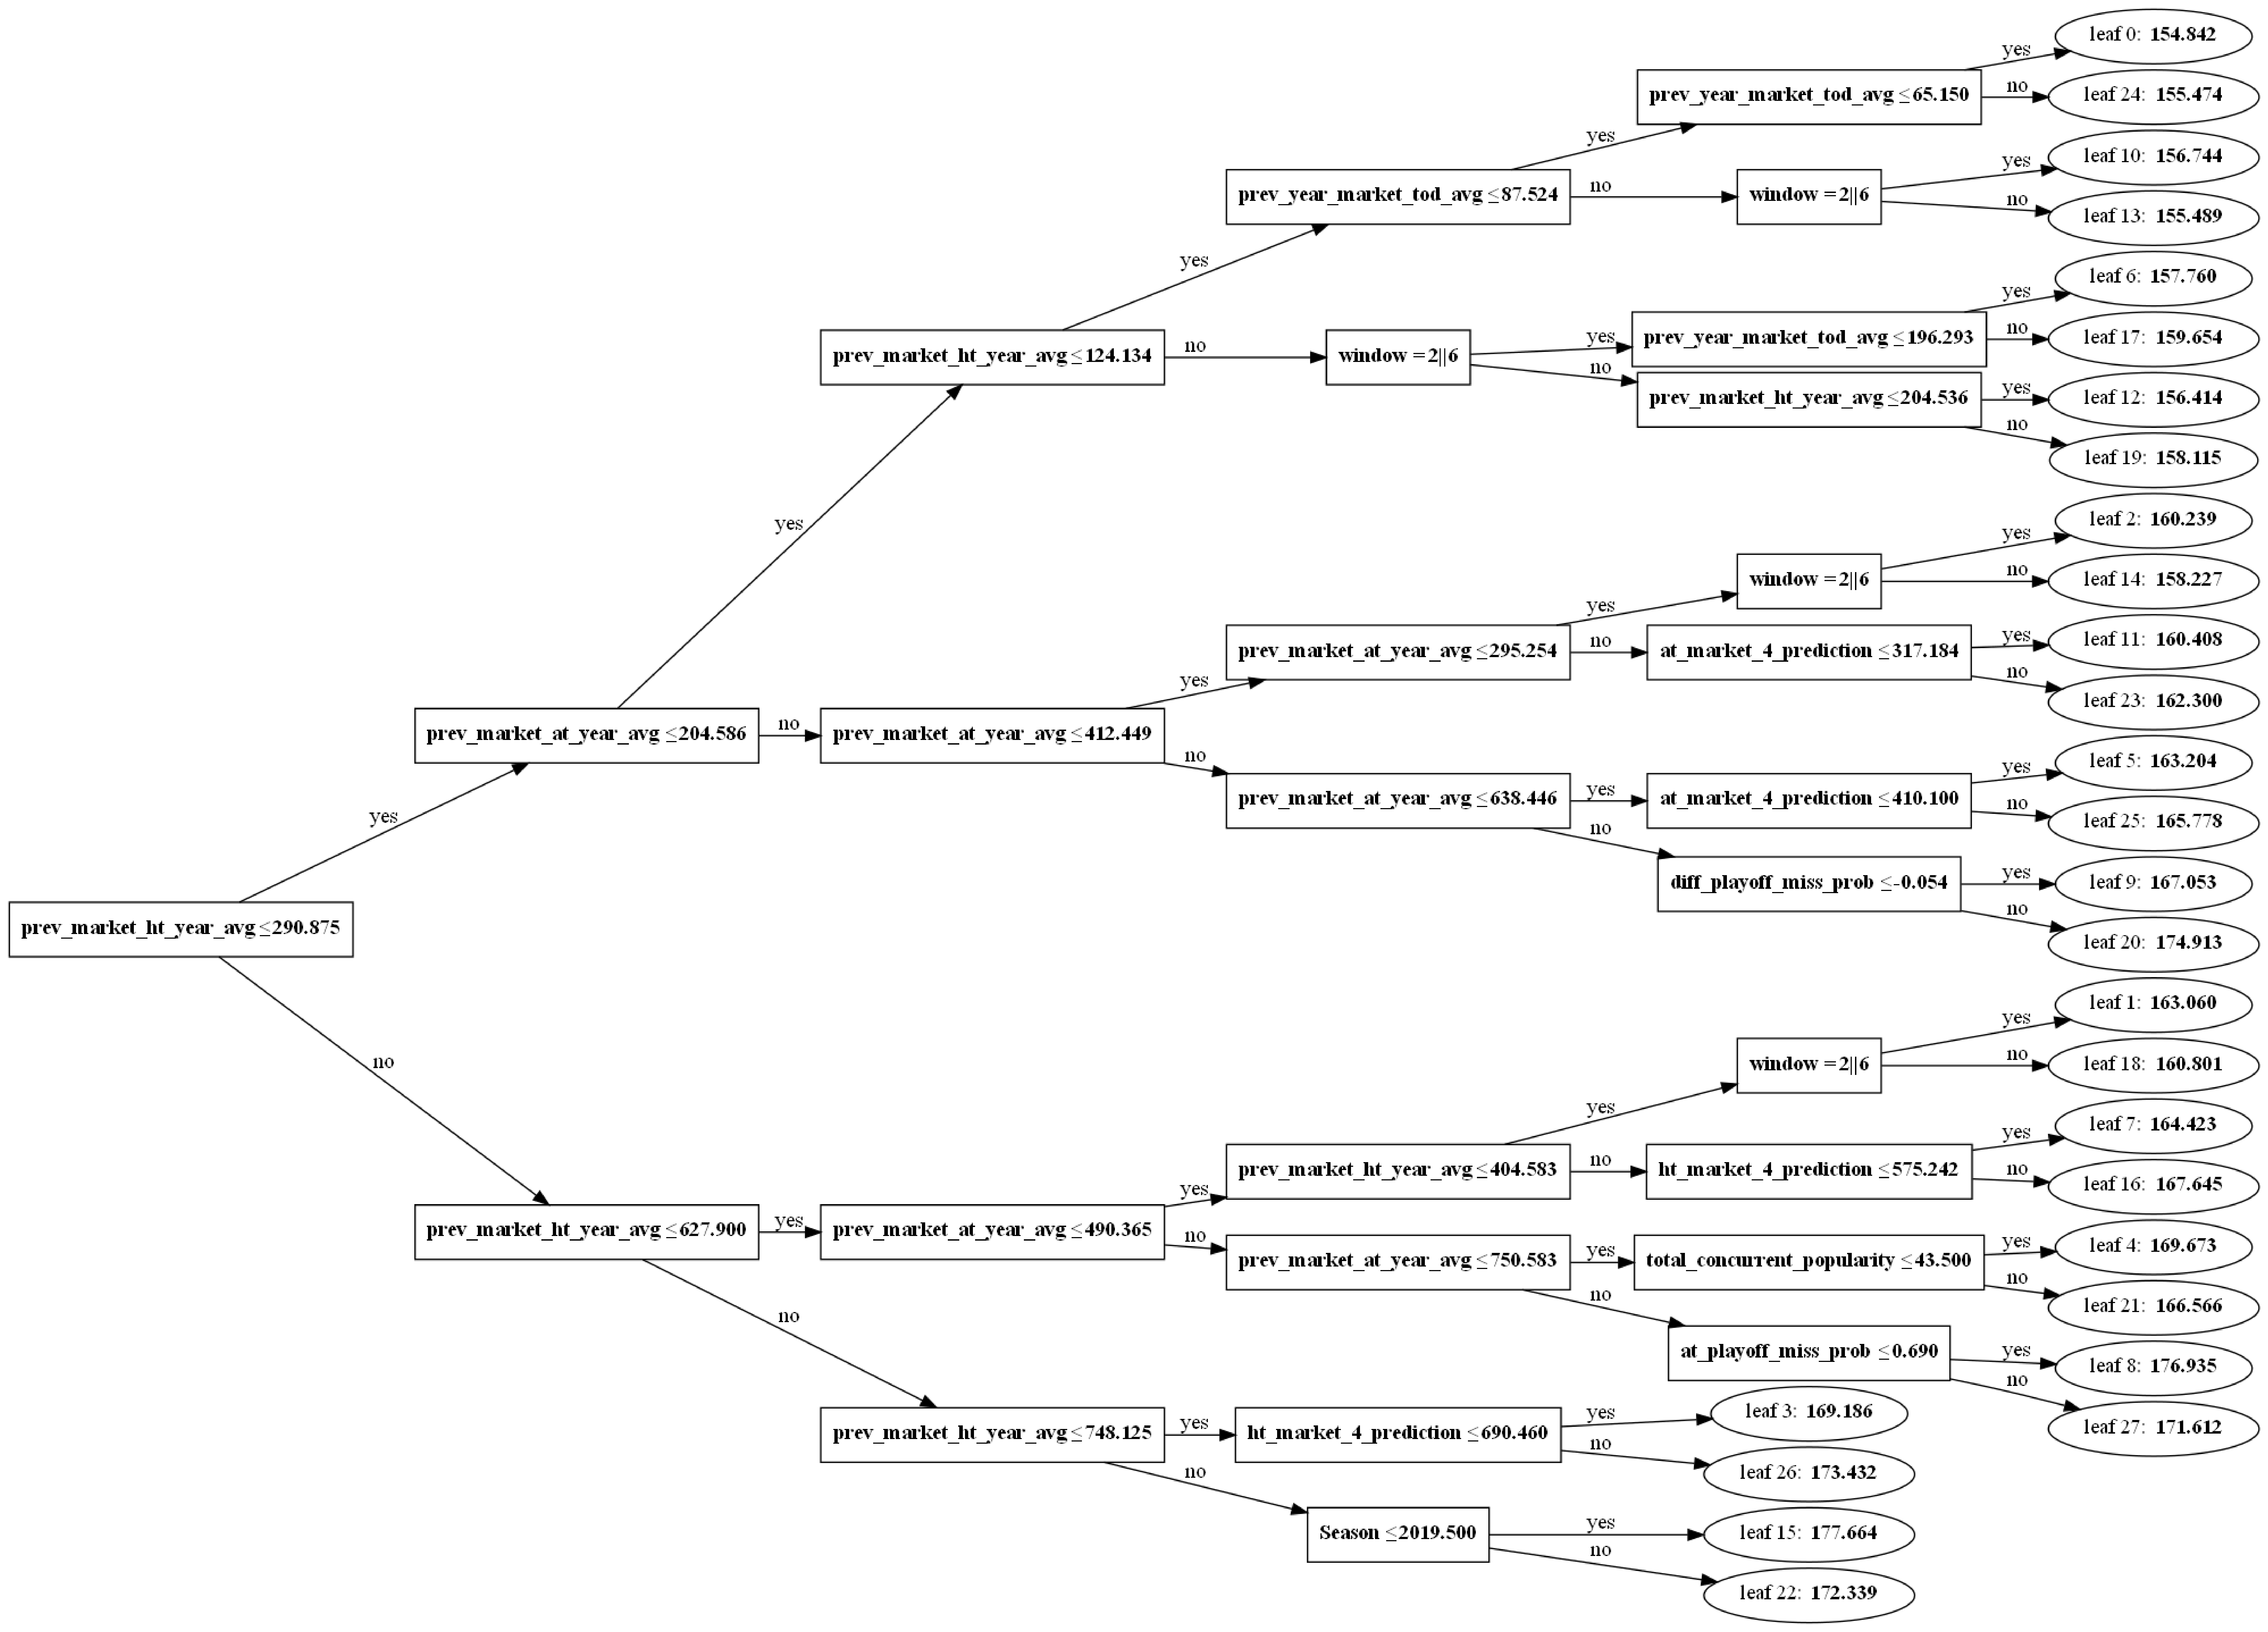

In [33]:
def show_lightgbm_tree(model, tree_index=0, figsize=(100, 50), dpi=120):
    ax = lgb.plot_tree(model, tree_index=tree_index, figsize=figsize)
    fig = ax.figure
    fig.set_dpi(dpi)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

show_lightgbm_tree(final_model, tree_index=0)

## 9. Artifacts & Persistence


In [ ]:
art_paths, cat_spec = save_lightgbm_artifacts_v2(
    model=final_model,
    X_with_categories=df_cat,
    categorical_features=cat_cols_sanitized,
    output_directory=SAVED_MODELS_DIR,
    study_nickname=STUDY_NICKNAME,
    extra_metadata={
        'target':         'AA__000_ (raw scale)',
        'avg_best_iter':  avg_best_iter,
        'oof_r2':         round(overall_r2, 6),
        'oof_rmse':       round(float(overall_rmse), 4),
        'phase1_best_r2': round(study1.best_value, 6),
        'phase2_best_r2': round(study2.best_value, 6),
        'n_features':     X_enc.shape[1],
        'n_train_rows':   len(df),
    },
)

# Save OOF predictions for downstream analysis
oof_path = os.path.join(SAVED_MODELS_DIR, f'oof_predictions_{STUDY_NICKNAME}.csv')
oof_df.to_csv(oof_path, index=False)
print(f"OOF predictions: {oof_path}")

# Save Optuna study summaries
for name, study in [('phase1', study1), ('phase2', study2)]:
    sp = os.path.join(SAVED_MODELS_DIR, f'optuna_{name}_{STUDY_NICKNAME}.csv')
    study.trials_dataframe().to_csv(sp, index=False)
    print(f"Optuna {name} trials: {sp}")

print("\nAll artifacts saved.")


In [35]:
print("=" * 55)
print("  FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"  Target            : AA__000_  (raw scale, no log transform)")
print(f"  CV strategy       : TimeSeriesSplit(n_splits=4, test_size={TEST_SIZE})")
print(f"  Features          : {X_enc.shape[1]} total (41 numerical/bool/concurrent + 7 categorical)")
print(f"  Optuna trials     : 300 (Phase 1) + 200 (Phase 2)")
print(f"  Avg best iteration: {avg_best_iter}")
print(f"  OOF R²            : {overall_r2:.4f}")
print(f"  OOF RMSE          : {overall_rmse:.2f}")
print()
print("  Baseline comparison:")
print(f"    Ridge (Linear)  : ~0.913")
print(f"    MLP (OHE)       : ~0.902")
print(f"    LightGBM (this) : {overall_r2:.4f}")
print("=" * 55)


  FINAL RESULTS SUMMARY
  Target            : AA__000_  (raw scale, no log transform)
  CV strategy       : TimeSeriesSplit(n_splits=4, test_size=4100)
  Features          : 168 total (41 numerical/bool/concurrent + 7 categorical)
  Optuna trials     : 300 (Phase 1) + 200 (Phase 2)
  Avg best iteration: 3343
  OOF R²            : 0.9152
  OOF RMSE          : 38.74

  Baseline comparison:
    Ridge (Linear)  : ~0.913
    MLP (OHE)       : ~0.902
    LightGBM (this) : 0.9152
